# Traffic Model

## Release AIM

lfc/maveric issues #2. **Create Non-Trivial and Interesting Dummy Trac Model to Demonstrate the Benet of Energy Savings**

## objectives

0. questions
1. function: bdt_traffic_load()
2. traffic load model
3. traffic load optimizer (TLO) metric
4. x_app for energy savings


## obj 1: function: bdt_traffic_load()

Write a function that takes relevant input parameters to generate realistic trac data for the following eight scenarios:

Scenarios:

- Annual: 
    - 2020 vs 2024 Comparison
- Monthly (Seasonal):
    - O-Season/Vacation vs Normal Trac Patterns
    - Other Seasonal Examples
Weekly- :
    - Weekdays vs Weekends
    - Other Weekly Patterns
- Daily:
    - Day vs Night
    - Other Daily Variations

### city story

> come up with a city story and write digital model of that city.

**Hell's Kitchen** (oh yes daredevil fan) is a small, eco-friendly city designed with sustainability and efficiency in mind. It has a population of ~100,000 and is divided into distinct areas:

- Office & Business Hub
    - Two office areas (Downtown Core & Wall Street) house corporate offices, government buildings, and co-working spaces.
    - High public transit usage during peak hours.

- Residential Zones
    - Two neighborhoods: North Greenfield (high-rise apartments) and Westwood Villas (suburban homes).
    - Traffic varies by time (morning rush, evening return, weekend outings).

- Transportation Hubs
    - Central Station (train & bus) near Downtown.
    - Multiple bus routes and bike lanes.

- Entertainment District
    - Shopping malls, movie theaters, and a concert arena.
    - Peak traffic in the evening and weekends.

- Green Park
    - A large recreational park with cycling paths and lakes.
    - Visitors peak on weekends and afternoons.

- Industrial Zone
    - A logistics hub for warehouses and factories.
    - High transport traffic with trucks and service vehicles.

| **City Area**             | **Bing Tile (X, Y, Zoom)** | **Traffic Type**  | **Morning Footfall** | **Afternoon Footfall** | **Evening Footfall** | **Night Footfall** |
|--------------------------|------------------------|------------------|------------------|-------------------|----------------|---------------|
| Downtown Core           | (10, 12, 5)            | Office          | High (1.5×)     | Low (0.9×)       | Moderate (1.0×) | Low (0.5×)   |
| Wall Street            | (11, 12, 5)            | Office          | High (1.5×)     | Low (0.9×)       | Moderate (1.0×) | Low (0.5×)   |
| North Greenfield (Res)  | (8, 15, 5)             | Resident        | Moderate (0.8×) | Low (0.9×)       | High (1.5×)   | Moderate (0.8×) |
| Westwood Villas (Res)   | (7, 16, 5)             | Resident        | Moderate (0.8×) | Low (0.9×)       | High (1.5×)   | Moderate (0.8×) |
| Central Station        | (9, 14, 5)             | Transport       | High (1.5×)     | Moderate (1.0×)  | Moderate (1.0×) | Moderate (0.8×) |
| Entertainment District  | (11, 13, 5)            | Entertainment   | Low (0.8×)      | High (1.2×)      | High (1.5×)   | Low (0.5×)   |
| Green Park             | (12, 14, 5)            | Comprehensive   | Low (0.8×)      | High (1.2×)      | Moderate (1.0×) | Moderate (0.8×) |
| Industrial Zone        | (6, 18, 5)             | Transport       | High (1.5×)     | Moderate (1.0×)  | Moderate (1.0×) | Moderate (0.8×) |


### footfall

> **Footfall** refers to the number of people passing through a specific location over a given period. Can be measured in `people/hr`.

Examples of Footfall in Different City Areas:

- Office Areas (Downtown Core, Wall Street)
    - High footfall in the morning (8-10 AM) as people arrive for work.
    - High again in the evening (5-7 PM) when they leave.
    - Low at night.

- Residential Areas (North Greenfield, Westwood Villas)
    - Moderate footfall in the morning as people leave for work.
    - High in the evening when they return home.
    - Low at night and during work hours.

- Transport Hubs (Central Station)
    - Footfall remains steady throughout the day with minor peaks during rush hours.

- Entertainment District (Shopping Malls, Theaters, Arenas)
    - High in the evening and on weekends.
    - Low during work hours.

- Parks & Recreational Areas (Green Park)
    - High in the afternoon and on weekends.
    - Low during early mornings and late nights.

- Industrial Zones
    - Footfall mainly consists of workers and transport staff, peaking during work hours (8 AM - 6 PM).

In [1]:
import sys
from pathlib import Path
sys.path.append(f"{Path().absolute().parent}")

In [2]:
from enum import Enum
from random import randint

In [3]:
class TRAFFIC_TYPE(Enum):
    OFFICE = "office"
    RESIDENT = "resident"
    TRANSPORT = "transport"
    ENTERTAINMENT = "entertainment"
    COMPREHENSIVE = "comprehensive"

In [4]:
class CityGrid:
    def __init__(self):
        self.areas = {
            "Downtown Core": {"bing_tile": (10, 12, 5), "traffic_type": TRAFFIC_TYPE.OFFICE},
            "Wall Street": {"bing_tile": (11, 12, 5), "traffic_type": TRAFFIC_TYPE.OFFICE},
            "North Greenfield": {"bing_tile": (8, 15, 5), "traffic_type": TRAFFIC_TYPE.RESIDENT},
            "Westwood Villas": {"bing_tile": (7, 16, 5), "traffic_type": TRAFFIC_TYPE.RESIDENT},
            "Central Station": {"bing_tile": (9, 14, 5), "traffic_type": TRAFFIC_TYPE.TRANSPORT},
            "Entertainment District": {"bing_tile": (11, 13, 5), "traffic_type": TRAFFIC_TYPE.ENTERTAINMENT},
            "Green Park": {"bing_tile": (12, 14, 5), "traffic_type": TRAFFIC_TYPE.COMPREHENSIVE},
            "Industrial Zone": {"bing_tile": (6, 18, 5), "traffic_type": TRAFFIC_TYPE.TRANSPORT},
        }
    
    def get_area_info(self, area_name):
        """Retrieve information about a specific area."""
        return self.areas.get(area_name, None)
    
    def simulate_footfall(self, area_name, time_of_day):
        """Simulate footfall at different times of the day."""
        area = self.get_area_info(area_name)
        if not area:
            return f"Invalid area: {area_name}"

        base_footfall = randint(100, 2000)  # Base pedestrian count in people/hr
        
        footfall_factor = {
            "morning": 1.5 if area["traffic_type"] in [TRAFFIC_TYPE.OFFICE, TRAFFIC_TYPE.TRANSPORT] else 0.8,
            "afternoon": 1.2 if area["traffic_type"] in [TRAFFIC_TYPE.ENTERTAINMENT, TRAFFIC_TYPE.COMPREHENSIVE] else 0.9,
            "evening": 1.5 if area["traffic_type"] in [TRAFFIC_TYPE.RESIDENT, TRAFFIC_TYPE.ENTERTAINMENT] else 1.0,
            "night": 0.5 if area["traffic_type"] in [TRAFFIC_TYPE.OFFICE, TRAFFIC_TYPE.ENTERTAINMENT] else 0.8,
        }

        footfall = int(base_footfall * footfall_factor.get(time_of_day, 1.0)) # people/hr
        
        return {
            "area": area_name,
            "time_of_day": time_of_day,
            "footfall": footfall
        }

In [5]:
city = CityGrid()

In [6]:
area_name = "Green Park"

city.get_area_info(area_name)

{'bing_tile': (12, 14, 5),
 'traffic_type': <TRAFFIC_TYPE.COMPREHENSIVE: 'comprehensive'>}

In [7]:
time_of_day = "morning"

city.simulate_footfall(area_name, time_of_day)

{'area': 'Green Park', 'time_of_day': 'morning', 'footfall': 949}

### generate traffic load data

- ue(s) remain inside in resident area say for tick 0-9 [area coordinates, tick range → hyper parameters]
- ue(s) remain inside in office area say for tick 10-18 [area coordinates, tick range → hyper parameter]
- Introduce a probabilistic feature: call ue generation functions say, 95 times for resident area and 5 times for office area for the same tick span 1-9 [probability → hyper parameter].
- Combine both/all areas into a map [map area → hyper parameter]
- Plot the ue data and visualize
- Address the ue blink issue from tick 9 → tick 10

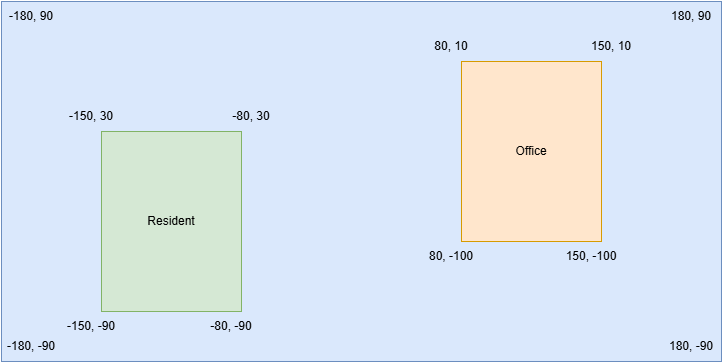

In [8]:
import sys
from pathlib import Path
sys.path.append(f"{Path().absolute().parent}")

In [9]:
import pandas as pd
from radp_library import get_ue_data, plot_ue_tracks

In [10]:
params = {
    "ue_tracks_generation": {
            "params": {
                "simulation_duration": 3600,
                "simulation_time_interval_seconds": 0.01,
                "num_ticks": 50,
                "num_batches": 1,
                "ue_class_distribution": {
                    "stationary": {
                        "count": 10,
                        "velocity": 0,
                        "velocity_variance": 1
                    },
                    "pedestrian": {
                        "count": 5,
                        "velocity": 2,
                        "velocity_variance": 1
                    },
                    "cyclist": {
                        "count": 5,
                        "velocity": 5,
                        "velocity_variance": 1
                    },
                    "car": {
                        "count": 12,
                        "velocity": 20,
                        "velocity_variance": 1
                    }
                },
                "lat_lon_boundaries": {
                    "min_lat": -90,
                    "max_lat": 90,
                    "min_lon": -180,
                    "max_lon": 180
                },
                "gauss_markov_params": {
                    "alpha": 0.5,
                    "variance": 0.8,
                    "rng_seed": 42,
                    "lon_x_dims": 100,
                    "lon_y_dims": 100,
                    "// TODO": "Account for supporting the user choosing the anchor_loc and cov_around_anchor.",
                    "// Current implementation": "the UE Tracks generator will not be using these values.",
                    "// anchor_loc": {},
                    "// cov_around_anchor": {}
            }
        }
    }
}

#### resident area ue generation
- ue(s) remain inside in resident area say for tick 0-9 [area coordinates, tick range → hyper parameters]

In [11]:
resident_params = params.copy()
resident_params["ue_tracks_generation"]["params"]["num_ticks"] = 10
resident_params["ue_tracks_generation"]["params"]["simulation_time_interval_seconds"] = 1
resident_params["ue_tracks_generation"]["params"]['lat_lon_boundaries'] = {
    "min_lat": -120,
    "max_lat": 30,
    "min_lon": -150,
    "max_lon": -80
}

In [12]:
resident_0_9 = get_ue_data(resident_params)

print(resident_0_9.shape)
print(resident_0_9['mock_ue_id'].nunique())
print(resident_0_9['tick'].nunique())

print(resident_0_9['mock_ue_id'].unique())
print(resident_0_9['tick'].unique())

resident_0_9.head()

(320, 4)
32
10
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
[0 1 2 3 4 5 6 7 8 9]


,mock_ue_id,lon,lat,tick
0,0,-105.341362,-58.537442,0
1,1,-111.287777,8.390300,0
2,2,-110.833644,-84.830665,0
3,3,-128.361812,-111.771484,0
4,4,-148.045587,-76.770798,0


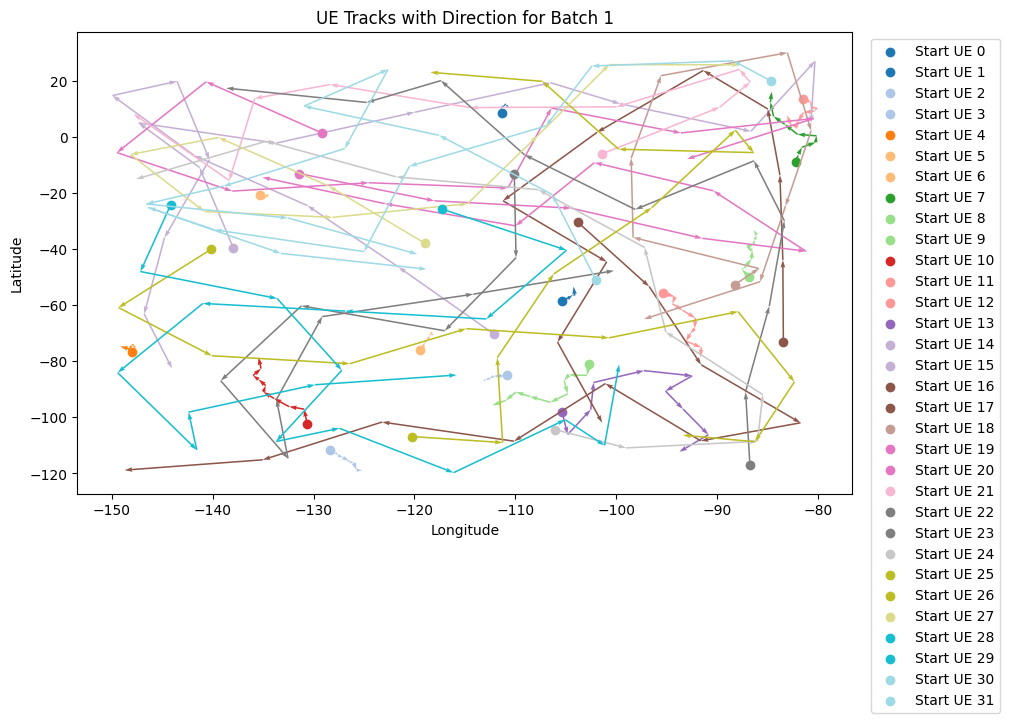

In [13]:
plot_ue_tracks(resident_0_9)

In [14]:
resident_0_9[['lon', 'lat', 'tick']].describe()

# ? what about the ue_class_distribution? this controls number of UE for each class and their velocity.
# ? what about the gauss_markov_params?
# ? In future how to incorporate the footfall data into the UE data?
# ? Using the get_ue_data function, how to map ue_id(s) as they always start from 0, just like ticks.
# TODO: for next area (office), need to update the ticks to make it 10-19.
# TODO: check for seed control, needed for introducing the probabilistic feature, otherwise the same data will be generated each time

,lon,lat,tick
count,320.000000,320.000000,320.00000
mean,-111.965983,-44.856967,4.50000
std,20.689539,42.526365,2.87678
min,-149.932796,-119.738357,0.00000
25%,-130.044090,-82.799836,2.00000
50%,-110.771615,-46.610949,4.50000
75%,-93.405981,-6.190144,7.00000
max,-80.095987,29.944973,9.00000


#### ue_id, tick sequencing

In [15]:
from radp.digital_twin.mobility.ue_tracks import UETracksGenerator
from radp.digital_twin.mobility.ue_tracks_params import UETracksGenerationParams
from radp.common import constants

In [16]:
def get_ue_data2(params: dict, start_id: int = 0, tick_start: int = 0) -> pd.DataFrame:
    """
    Generates user equipment (UE) tracks data using specified simulation parameters.

    This function initializes a UETracksGenerationParams object using the provided parameters
    and then iterates over batches generated by the UETracksGenerator. Each batch of UE tracks
    data is consolidated into a single DataFrame which captures mobility tracks across multiple
    ticks and batches, as per the defined parameters.

    The UE tracks are returned in form of a dataframe with mock_ue_id starting from `start_id`.

    Parameters:
        - params (dict): Dictionary of simulation parameters.
        - start_id (int): The starting UE ID for the generated data. Default is 0.

    Returns:
        - pd.DataFrame: DataFrame containing UE tracks, with columns mock_ue_id, lon, lat, tick.
    """
    
    # Initialize the UE data
    ue_tracks_params = UETracksGenerationParams(params)

    ue_tracks_generation = pd.DataFrame()  # Initialize an empty DataFrame
    for ue_tracks_generation_batch in UETracksGenerator.generate_as_lon_lat_points(
        rng_seed=ue_tracks_params.rng_seed,
        lon_x_dims=ue_tracks_params.lon_x_dims,
        lon_y_dims=ue_tracks_params.lon_y_dims,
        num_ticks=ue_tracks_params.num_ticks,
        num_UEs=ue_tracks_params.num_UEs,
        num_batches=ue_tracks_params.num_batches,
        alpha=ue_tracks_params.alpha,
        variance=ue_tracks_params.variance,
        min_lat=ue_tracks_params.min_lat,
        max_lat=ue_tracks_params.max_lat,
        min_lon=ue_tracks_params.min_lon,
        max_lon=ue_tracks_params.max_lon,
        mobility_class_distribution=ue_tracks_params.mobility_class_distribution,
        mobility_class_velocities=ue_tracks_params.mobility_class_velocities,
        mobility_class_velocity_variances=ue_tracks_params.mobility_class_velocity_variances,
    ):
        # Modify the mock_ue_id to start from start_id
        ue_tracks_generation_batch[constants.MOCK_UE_ID] += start_id
        
        # Modify the tick values to start from tick_start
        ue_tracks_generation_batch["tick"] += tick_start        
        
        # Append each batch to the main DataFrame
        ue_tracks_generation = pd.concat([ue_tracks_generation, ue_tracks_generation_batch], ignore_index=True)

    return ue_tracks_generation


In [17]:
starting_ue_tick = {
    'start_id' : 100,
    'tick_start' : 10
}
data2 = get_ue_data2(params, **starting_ue_tick)

In [18]:
data2

,mock_ue_id,lon,lat,tick
0,100,-105.341362,-58.537442,10
1,101,-111.287777,8.390300,10
2,102,-110.833644,-84.830665,10
3,103,-128.361812,-111.771484,10
4,104,-148.045587,-76.770798,10
...,...,...,...,...
315,127,-87.754554,25.617931,19
316,128,-115.814915,-84.937403,19
317,129,-99.711018,-81.157816,19
318,130,-119.720371,-41.846073,19


In [19]:
data2[['mock_ue_id', 'tick']].describe()

,mock_ue_id,tick
count,320.000000,320.00000
mean,115.500000,14.50000
std,9.247553,2.87678
min,100.000000,10.00000
25%,107.750000,12.00000
50%,115.500000,14.50000
75%,123.250000,17.00000
max,131.000000,19.00000


#### office area ue generation

In [20]:
office_params = params.copy()
office_params["ue_tracks_generation"]["params"]["num_ticks"] = 10
office_params["ue_tracks_generation"]["params"]["simulation_time_interval_seconds"] = 1
office_params["ue_tracks_generation"]["params"]['lat_lon_boundaries'] = {
    "min_lat": -100,
    "max_lat": 10,
    "min_lon": 80,
    "max_lon": 150
}

In [21]:
starting_ue_tick = {
    'start_id' : 32,
    'tick_start' : 10
}

office_0_9 = get_ue_data2(office_params, **starting_ue_tick)

print(office_0_9.shape)
print(office_0_9['mock_ue_id'].nunique())
print(office_0_9['tick'].nunique())

print(office_0_9['mock_ue_id'].unique())
print(office_0_9['tick'].unique())

office_0_9.head()

(320, 4)
32
10
[32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55
 56 57 58 59 60 61 62 63]
[10 11 12 13 14 15 16 17 18 19]


,mock_ue_id,lon,lat,tick
0,32,124.658638,-54.927457,10
1,33,118.712223,-5.847113,10
2,34,119.166356,-74.209154,10
3,35,101.638188,-93.965755,10
4,36,81.954413,-68.298585,10


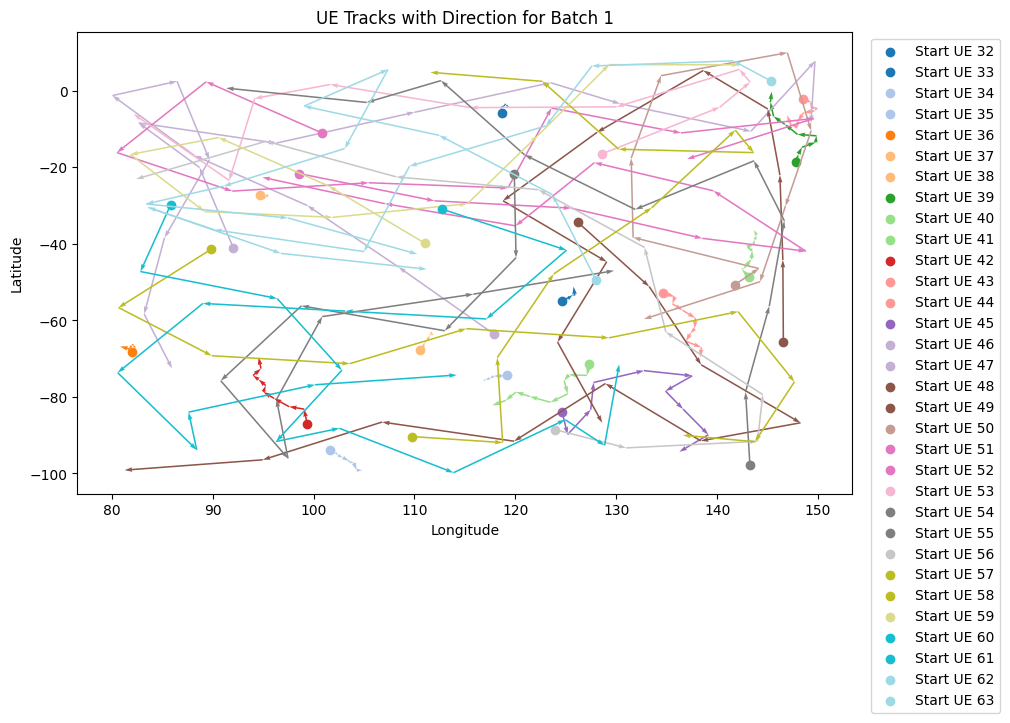

In [22]:
plot_ue_tracks(office_0_9)

#### initial city data

In [23]:
combined_df = pd.concat([resident_0_9, office_0_9], ignore_index=True)
print(combined_df.shape)
combined_df.head()

(640, 4)


,mock_ue_id,lon,lat,tick
0,0,-105.341362,-58.537442,0
1,1,-111.287777,8.390300,0
2,2,-110.833644,-84.830665,0
3,3,-128.361812,-111.771484,0
4,4,-148.045587,-76.770798,0


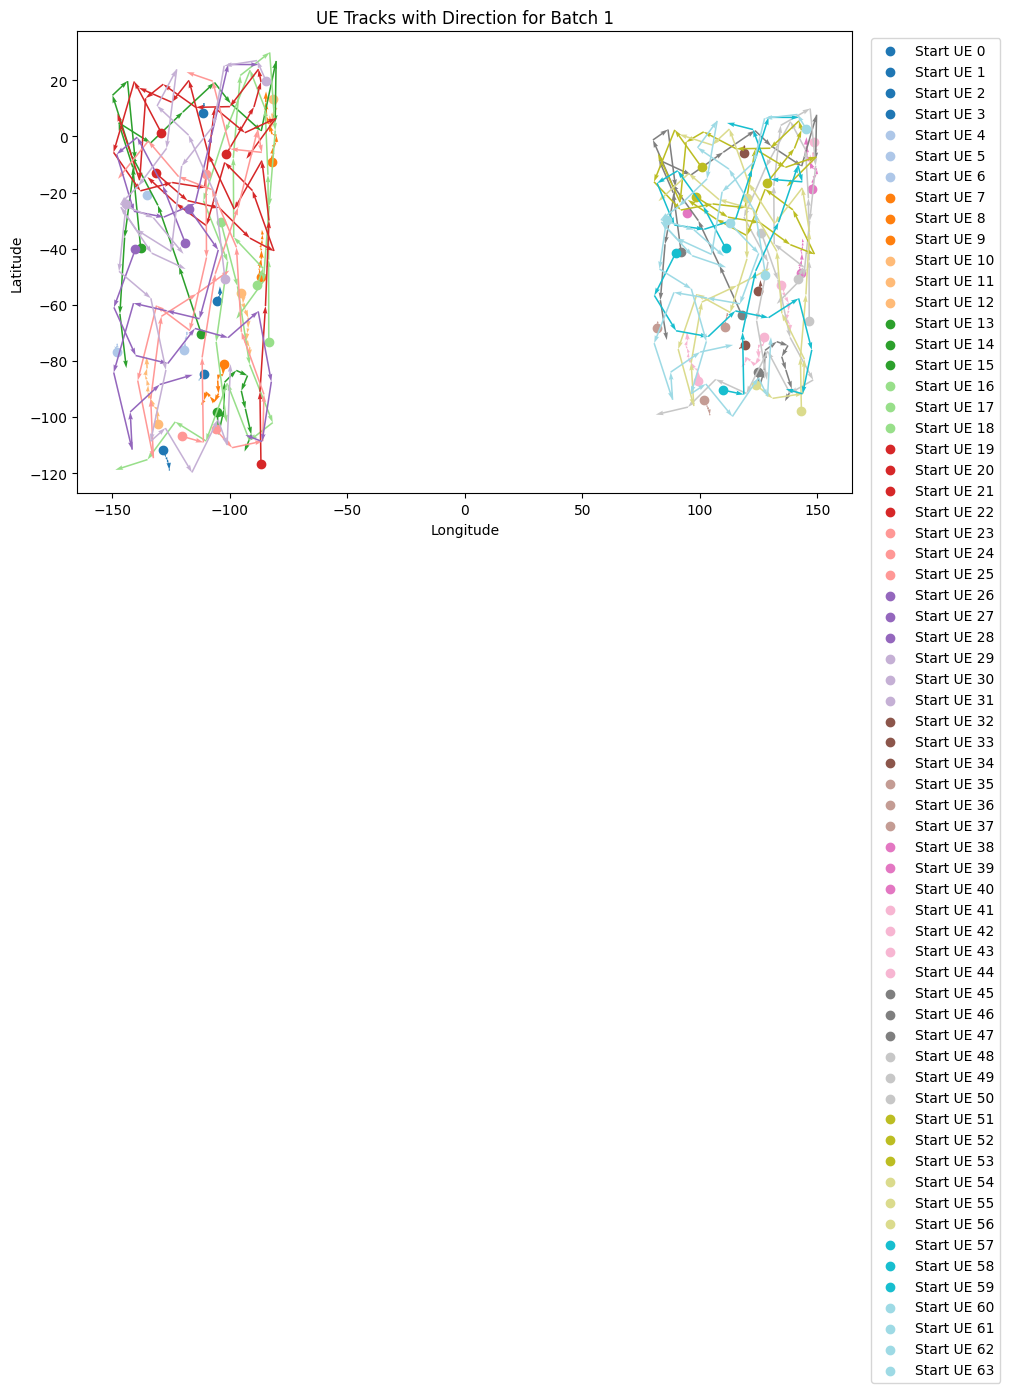

In [24]:
plot_ue_tracks(combined_df)

### Component generator

In [ ]:
import random, math

def generate_components(num_components=5, min_size=5, max_size=20, min_lat_bound=-90, max_lat_bound=90, min_lon_bound=-180, max_lon_bound=180, seed=None):
    """
    Generate non-overlapping rectangular components with latitude and longitude bounds.

    Parameters:
    - num_components (int): Number of components/areas to generate.
    - min_size (float): Minimum size of the component (in degrees). Dictates the width and height of the component.
    - max_size (float): Maximum size of the component (in degrees). Dictates the width and height of the component.
    - min_lat_bound (float): Minimum latitude boundary for component placement.
    - max_lat_bound (float): Maximum latitude boundary for component placement.
    - min_lon_bound (float): Minimum longitude boundary for component placement.
    - max_lon_bound (float): Maximum longitude boundary for component placement.
    - seed (int, optional): Random seed for reproducibility.

    Returns:
    - list: A list of dictionaries, each containing:
        - component_id (int): Unique identifier for the component.
        - bounds (tuple): Latitude and longitude bounds of the component (min_lat, max_lat, min_lon, max_lon).
        - area (float): Area of the component in square kilometers, approximately.
    """
    if seed is not None:
        random.seed(seed)
    
    components = []
    used_areas = []  # Stores placed areas to check overlap
    
    for i in range(num_components):
        while True:
            # Generate random size within constraints
            width = random.uniform(min_size, max_size)
            height = random.uniform(min_size, max_size)
            
            # Generate random bottom-left corner
            min_lat = random.uniform(min_lat_bound, max_lat_bound - height)
            min_lon = random.uniform(min_lon_bound, max_lon_bound - width)
            
            # Compute top-right corner
            max_lat = min_lat + height
            max_lon = min_lon + width
            
            new_area = (min_lat, max_lat, min_lon, max_lon)
            
            # overlap check
            if any(
                not (new_area[1] <= old[0] or new_area[0] >= old[1] or
                     new_area[3] <= old[2] or new_area[2] >= old[3])  
                for old in used_areas
            ):
                continue  # Retry if overlapping
            
            # Store area and assign component
            used_areas.append(new_area)
            
            # Calculate area in km^2
            lat_km_per_degree = 111  # Approximate conversion factor
            lon_km_per_degree = 111 * abs(math.cos(math.radians((min_lat + max_lat) / 2)))  # Varies with latitude
            area = width * lon_km_per_degree * height * lat_km_per_degree
            
            components.append({
                "component_id": i + 1,
                "bounds": new_area,  # (min_lat, max_lat, min_lon, max_lon)
                "area": round(area, 2)
            })
            break
    
    return components



In [129]:
components = generate_components()
for comp in components:
    print(comp)

{'component_id': 1, 'bounds': (-15.515607539929235, -3.757890566597922, 118.61667424036449, 131.45526226731775), 'area': 1833640.47}
{'component_id': 2, 'bounds': (15.835039062055827, 25.415742726846233, 27.365668939977695, 47.21613784697966), 'area': 2193033.26}
{'component_id': 3, 'bounds': (-56.59058323044646, -37.376730225565794, -107.42871802008511, -91.32737843781695), 'area': 2600390.48}
{'component_id': 4, 'bounds': (-59.99210880322946, -52.636252402516305, -154.09559581313982, -139.18917375525928), 'area': 749311.9}
{'component_id': 5, 'bounds': (9.904246997251136, 21.66180256651667, -76.61464232992961, -71.57450649088632), 'area': 702611.25}


**note**: the areas are humungous. need to work with `min_size` and `max_size`

In [131]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_components(components):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Set map limits (world map projection)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    
    # Draw a world map grid
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Generated Component Areas")

    # Plot each component as a rectangle
    for idx, component in enumerate(components):
        min_lat, max_lat, min_lon, max_lon = component['bounds']
        width = max_lon - min_lon
        height = max_lat - min_lat

        rect = patches.Rectangle(
            (min_lon, min_lat), width, height, 
            linewidth=2, edgecolor='r', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(min_lon + width / 2, min_lat + height / 2, f"{idx+1}", fontsize=10, ha='center', va='center')

    plt.show()


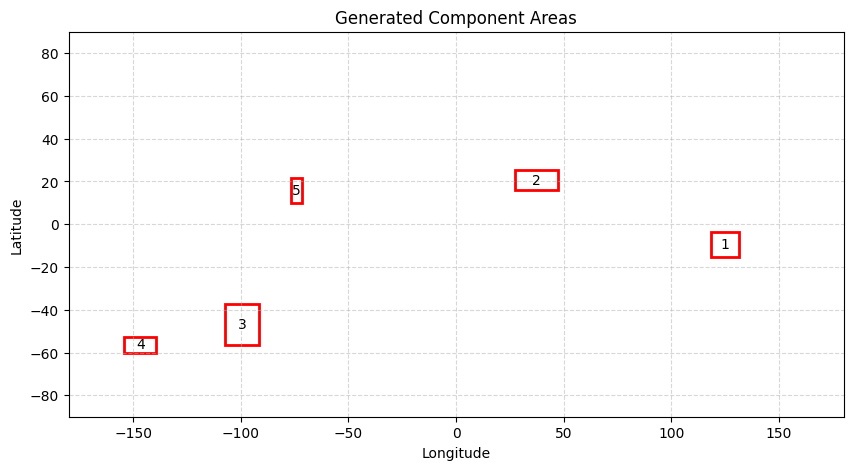

In [132]:
plot_components(components)

In [133]:
# generate + plot

def gen_plot(num_components, min_size, max_size):
    components = generate_components(num_components, min_size, max_size)
    plot_components(components)
    
    return components

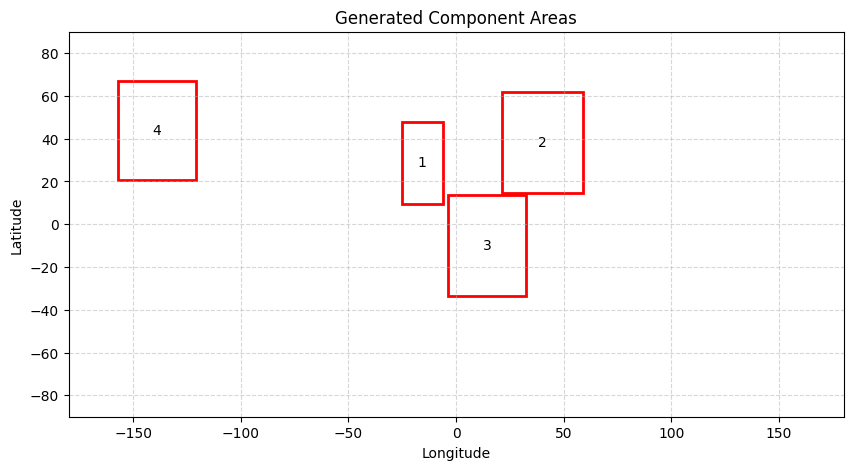

In [134]:
comp_params = {
    "num_components": 4,
    "min_size": 10,
    "max_size": 50
}

components = gen_plot(**comp_params)

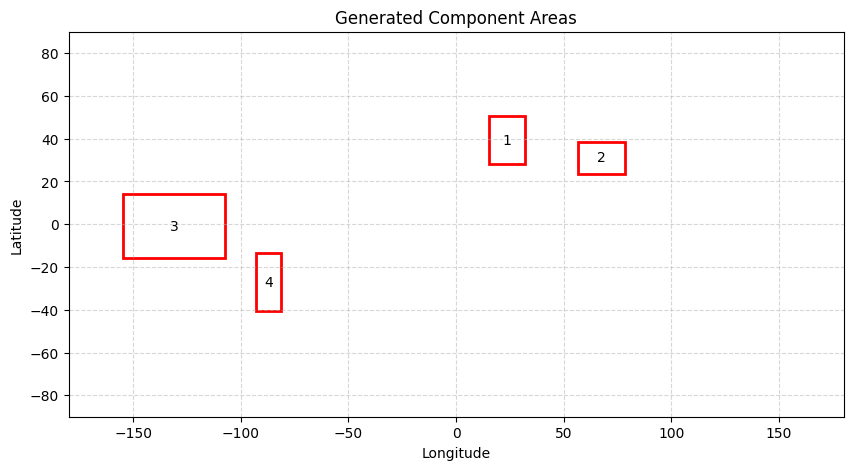

In [135]:
components = gen_plot(**comp_params)

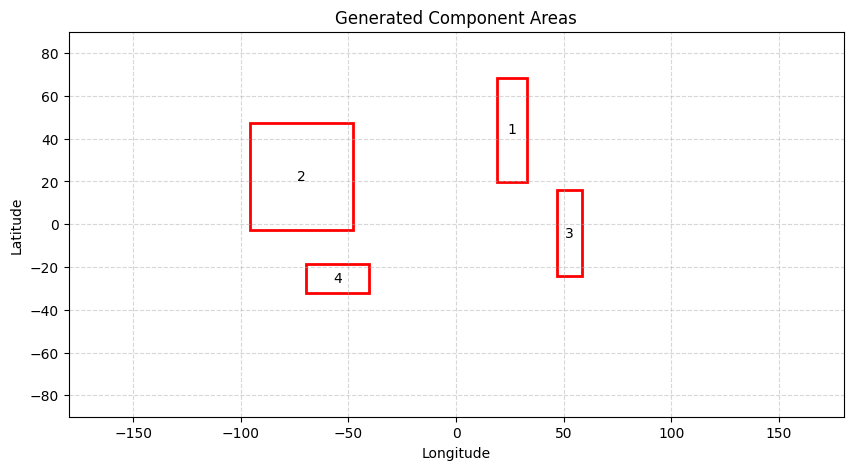

In [136]:
components = gen_plot(**comp_params)

#### 2 areas trial

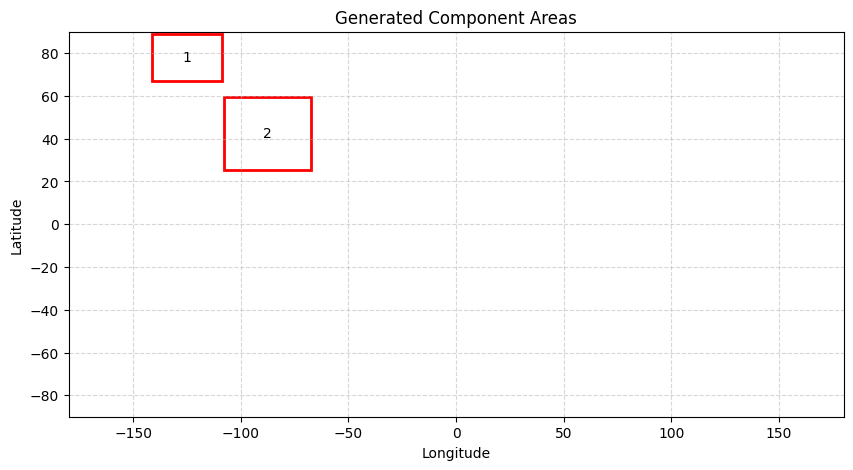

In [115]:
comp_params = {
    "num_components": 2,
    "min_size": 10,
    "max_size": 50
}

components = gen_plot(**comp_params)

In [116]:
components

[{'component_id': 1,
  'bounds': (66.88657599902041,
   89.03999647270952,
   -141.2087224079539,
   -108.69513852457133),
  'area': 1850707.03},
 {'component_id': 2,
  'bounds': (25.248336165678367,
   59.50104221539688,
   -107.91050413218989,
   -67.33276631914211),
  'area': 12651092.19}]

In [117]:
min_lat, max_lat, min_lon, max_lon = components[0]['bounds']

office_params = params.copy()
office_params["ue_tracks_generation"]["params"]["num_ticks"] = 10
office_params["ue_tracks_generation"]["params"]["simulation_time_interval_seconds"] = 1
office_params["ue_tracks_generation"]["params"]['lat_lon_boundaries'] = {
    "min_lat": min_lat,
    "max_lat": max_lat,
    "min_lon": min_lon,
    "max_lon": max_lon,
}

In [119]:
office_1 = get_ue_data2(office_params)

office_1

,mock_ue_id,lon,lat,tick
0,0,-120.465689,75.963949,0
1,1,-123.227678,85.848471,0
2,2,-123.016743,72.080716,0
3,3,-131.158222,68.101841,0
4,4,-140.300937,73.271074,0
...,...,...,...,...
315,27,-112.296972,88.392811,9
316,28,-125.330442,72.064952,9
317,29,-117.850508,72.623158,9
318,30,-127.144447,78.429088,9


In [121]:
min_lat, max_lat, min_lon, max_lon = components[1]['bounds']

resident_params = params.copy()
resident_params["ue_tracks_generation"]["params"]["num_ticks"] = 10
resident_params["ue_tracks_generation"]["params"]["simulation_time_interval_seconds"] = 1
resident_params["ue_tracks_generation"]["params"]['lat_lon_boundaries'] = {
    "min_lat": min_lat,
    "max_lat": max_lat,
    "min_lon": min_lon,
    "max_lon": max_lon,
}

In [126]:
starting_ue_tick = {
    'start_id' : 32,
    'tick_start' : 10
}

resident_1 = get_ue_data2(resident_params, **starting_ue_tick)

resident_1

,mock_ue_id,lon,lat,tick
0,32,-82.022697,39.283396,10
1,33,-85.469727,54.566438,10
2,34,-85.206474,33.279302,10
3,35,-95.367237,27.127329,10
4,36,-106.777566,35.119784,10
...,...,...,...,...
315,59,-71.827941,58.500391,19
316,60,-88.094027,33.254928,19
317,61,-78.758888,34.118002,19
318,62,-90.357949,43.094893,19


In [127]:
merged_df = pd.concat([office_1, resident_1], ignore_index=True)
print(merged_df.shape)
merged_df.head()

(640, 4)


,mock_ue_id,lon,lat,tick
0,0,-120.465689,75.963949,0
1,1,-123.227678,85.848471,0
2,2,-123.016743,72.080716,0
3,3,-131.158222,68.101841,0
4,4,-140.300937,73.271074,0


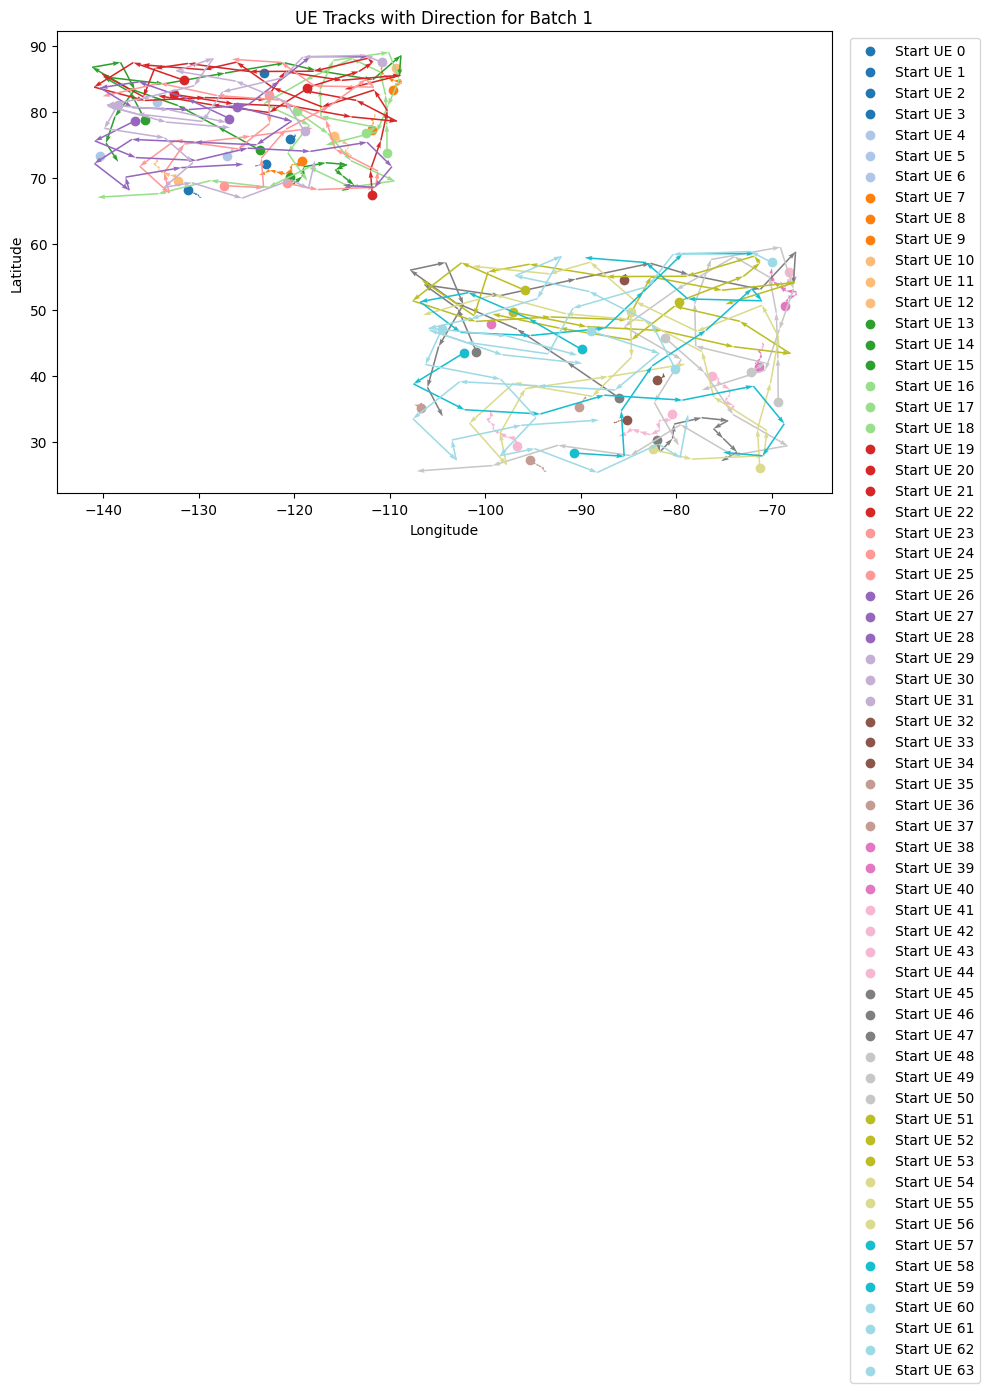

In [128]:
plot_ue_tracks(merged_df)